In [4]:
# Simple dataset generator using the finalized two-neuron simulation API

import os
os.environ["JAX_PLATFORMS"] = "cpu"     
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import jax
import jax.numpy as jnp
from jax import random

from TwoNeuron_JAX import (   
    ModelParams, NoiseParams,
    simulate_pair_jit,   # runs the soft LIF model and gives (C,F)
    noisy_F,             # adds noise based on heteroscedastic model
)

# Settings
N_SAMPLES = 100000
W_MIN, W_MAX = 6.0, 10.0

SIGMA_C = 28.0
SIGMA_F = 4e-4
GAMMA   = 1e-4

SAVE_X = "X1_test.npy"
SAVE_Y = "Y1_test.npy"

# Random number generators
np_rng = np.random.default_rng(1234)  # for sampling weights
jax_key = random.PRNGKey(1234)        # for JAX noise draws

# Simulator configuration
cfg = ModelParams()
noise = NoiseParams(sigma_f=SIGMA_F, gamma=GAMMA, sigma_c=SIGMA_C, floor=1e-3)

# Each fluorescence trace has length = total time / calcium bin
T_ca = int(round(cfg.sim_time / cfg.ca_bin))  

# Allocate arrays for storage
X = np.empty(N_SAMPLES, dtype=np.float32)
Y = np.empty((N_SAMPLES, 2, T_ca), dtype=np.float32)

# Generate dataset
i = 0
while i < N_SAMPLES:
    # pick a random synaptic weight
    w = np_rng.uniform(W_MIN, W_MAX)

    # deterministic forward pass (clean calcium and fluorescence)
    C_clean, F_clean = simulate_pair_jit(float(w), cfg)

    # draw noisy fluorescence using JAX random key
    jax_key, subkey = random.split(jax_key)
    F_noisy, _ = noisy_F(F_clean, C_clean, cfg, noise, subkey)

    # save to arrays
    X[i]        = np.float32(w)
    Y[i, 0, :]  = np.asarray(F_noisy[0], dtype=np.float32)
    Y[i, 1, :]  = np.asarray(F_noisy[1], dtype=np.float32)

    i += 1
    if i % 1000 == 0:
        print(f"{i} samples generated")

# Save results
np.save(SAVE_X, X)                  # (N_SAMPLES,)
np.save(SAVE_Y, Y)                  # (N_SAMPLES, 2, T_ca)
print(f"Done! Saved {SAVE_X} and {SAVE_Y}")


1000 samples generated
2000 samples generated
3000 samples generated
4000 samples generated
5000 samples generated
6000 samples generated
7000 samples generated
8000 samples generated
9000 samples generated
10000 samples generated
11000 samples generated
12000 samples generated
13000 samples generated
14000 samples generated
15000 samples generated
16000 samples generated
17000 samples generated
18000 samples generated
19000 samples generated
20000 samples generated
21000 samples generated
22000 samples generated
23000 samples generated
24000 samples generated
25000 samples generated
26000 samples generated
27000 samples generated
28000 samples generated
29000 samples generated
30000 samples generated
31000 samples generated
32000 samples generated
33000 samples generated
34000 samples generated
35000 samples generated
36000 samples generated
37000 samples generated
38000 samples generated
39000 samples generated
40000 samples generated
41000 samples generated
42000 samples generated
4

C:\Users\Suman\AppData\Local\Temp\ipykernel_53612\1951306020.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.09, 1, 0.97])  # increased bottom margin (0.07 → 0.09)


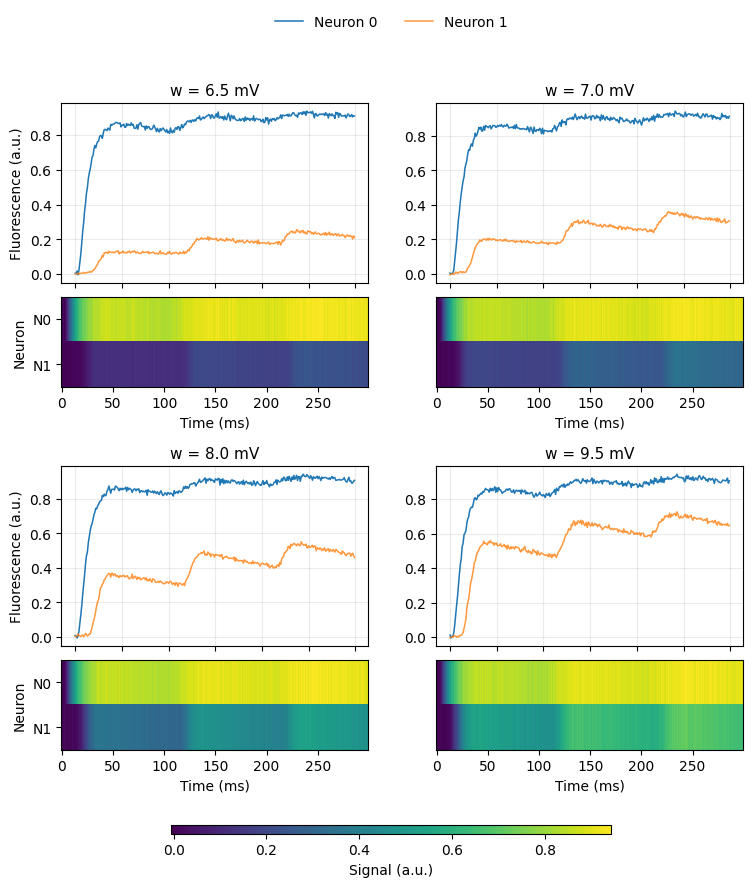

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Load data
X = np.load("X1_test.npy")
Y = np.load("Y1_test.npy")

weights_to_plot = [6.5, 7.0, 8.0, 9.5]

fig = plt.figure(figsize=(8.8, 8.4))
gs = GridSpec(2, 2, figure=fig, hspace=0.28, wspace=0.22)

for i, w_target in enumerate(weights_to_plot):
    r, c = divmod(i, 2)
    idx = (np.abs(X - w_target)).argmin()
    trace0, trace1 = Y[idx, 0, :], Y[idx, 1, :]
    t_ms = np.arange(trace0.size)

    # Sub-grid for traces + heatmap inside each panel
    inner_gs = gs[r, c].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.1)
    
    # Traces 
    ax1 = fig.add_subplot(inner_gs[0])
    ln1 = ax1.plot(t_ms, trace0, color='tab:blue', lw=1.1, label='Neuron 0')[0]
    ln2 = ax1.plot(t_ms, trace1, color='tab:orange', lw=1.1, label='Neuron 1', alpha=0.8)[0]
    ax1.set_title(f'w = {X[idx]:.1f} mV', fontsize=11)
    ax1.set_xticklabels([])
    ax1.grid(alpha=0.25)
    if c == 0:
        ax1.set_ylabel('Fluorescence (a.u.)')

    # Heatmap 
    ax2 = fig.add_subplot(inner_gs[1])
    im = ax2.imshow(np.vstack([trace0, trace1]), aspect='auto', cmap='viridis', interpolation='nearest')
    if c == 0:
        ax2.set_yticks([0, 1])
        ax2.set_yticklabels(['N0', 'N1'])
        ax2.set_ylabel('Neuron')
    else:
        ax2.set_yticks([])
    ax2.set_xlabel('Time (ms)')

# Shared legend and colorbar
fig.legend([ln1, ln2], ['Neuron 0', 'Neuron 1'], loc='upper center',
           ncol=2, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 1.0))

# Shared colorbar =
cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.01])  # lowered from 0.05 → 0.04
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Signal (a.u.)', labelpad=4)

# Final layout
plt.tight_layout(rect=[0, 0.09, 1, 0.97])  
plt.savefig("plots/abc.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Generate multiple noisy samples for each fixed weight using the finalized API

import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import jax
from jax import random

from TwoNeuron_JAX import (   
    ModelParams, NoiseParams,
    simulate_pair_jit,
    noisy_F,
)

# number of noisy samples per weight
N_SAMPLES = 1000
FIXED_WEIGHTS = [6.5, 7.0, 8.0, 9.5]

# random key for noise
jax_key = random.PRNGKey(1234)

# simulator config and noise model
cfg = ModelParams()
noise = NoiseParams(
    sigma_f=4e-4,
    gamma=1e-4,
    sigma_c=28.0,
    floor=1e-3,
)

T_ca = int(round(cfg.sim_time / cfg.ca_bin))  

for w in FIXED_WEIGHTS:
    print(f"Generating {N_SAMPLES} noisy samples for w={w:.1f} mV...")

    X = np.full((N_SAMPLES,), np.float32(w))
    Y = np.empty((N_SAMPLES, 2, T_ca), dtype=np.float32)

    for i in range(N_SAMPLES):
        # deterministic forward
        C_clean, F_clean = simulate_pair_jit(float(w), cfg)

        # add noise
        jax_key, subkey = random.split(jax_key)
        F_noisy, _ = noisy_F(F_clean, C_clean, cfg, noise, subkey)

        Y[i, 0, :] = np.asarray(F_noisy[0], dtype=np.float32)
        Y[i, 1, :] = np.asarray(F_noisy[1], dtype=np.float32)

        if (i + 1) % 200 == 0:
            print(f"  {i+1} / {N_SAMPLES} done")

    # save with clear file names
    np.save(f"X_w{w}.npy", X)
    np.save(f"Y_w{w}.npy", Y)
    print(f"Saved X_w{w}.npy {X.shape}, Y_w{w}.npy {Y.shape}")


Generating 1000 noisy samples for w=6.5 mV...
  200 / 1000 done
  400 / 1000 done
  600 / 1000 done
  800 / 1000 done
  1000 / 1000 done
Saved X_w6.5.npy (1000,), Y_w6.5.npy (1000, 2, 300)
Generating 1000 noisy samples for w=7.0 mV...
  200 / 1000 done
  400 / 1000 done
  600 / 1000 done
  800 / 1000 done
  1000 / 1000 done
Saved X_w7.0.npy (1000,), Y_w7.0.npy (1000, 2, 300)
Generating 1000 noisy samples for w=8.0 mV...
  200 / 1000 done
  400 / 1000 done
  600 / 1000 done
  800 / 1000 done
  1000 / 1000 done
Saved X_w8.0.npy (1000,), Y_w8.0.npy (1000, 2, 300)
Generating 1000 noisy samples for w=9.5 mV...
  200 / 1000 done
  400 / 1000 done
  600 / 1000 done
  800 / 1000 done
  1000 / 1000 done
Saved X_w9.5.npy (1000,), Y_w9.5.npy (1000, 2, 300)
